In [17]:
import pandas as pd
import numpy as np

print("Libraries loaded")


Libraries loaded


In [18]:
from pathlib import Path

csv_text = """age,sex,bmi,children,smoker,region,charges
19,female,27.9,0,yes,southwest,16884.92
18,male,33.77,1,no,southeast,1725.55
28,male,33.0,3,no,southeast,4449.46
33,male,22.705,0,no,northwest,21984.47
32,male,28.88,0,no,northwest,3866.85
31,female,25.74,0,no,southeast,3756.62
46,female,33.44,1,no,southeast,8240.59
37,female,27.74,3,no,northwest,7281.51
37,male,29.83,2,no,northeast,6406.41
60,female,25.84,0,no,northwest,28923.14
"""

path = Path("../data/insurance.csv")
path.parent.mkdir(parents=True, exist_ok=True)
path.write_text(csv_text, encoding="utf-8")

print("Wrote:", path.resolve())
print("Size (bytes):", path.stat().st_size)


Wrote: C:\Users\Pavan\Downloads\medical-insurance\ml\data\insurance.csv
Size (bytes): 437


In [19]:
df = pd.read_csv("../data/insurance.csv")
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92
1,18,male,33.770,1,no,southeast,1725.55
2,28,male,33.000,3,no,southeast,4449.46
3,33,male,22.705,0,no,northwest,21984.47
4,32,male,28.880,0,no,northwest,3866.85


In [20]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       10 non-null     int64  
 1   sex       10 non-null     object 
 2   bmi       10 non-null     float64
 3   children  10 non-null     int64  
 4   smoker    10 non-null     object 
 5   region    10 non-null     object 
 6   charges   10 non-null     float64
dtypes: float64(2), int64(2), object(3)
memory usage: 688.0+ bytes


,age,bmi,children,charges
count,10.000000,10.000000,10.000000,10.000000
mean,34.100000,28.884500,1.000000,10351.952000
std,12.332883,3.682907,1.247219,9111.324518
min,18.000000,22.705000,0.000000,1725.550000
25%,28.750000,26.315000,0.000000,4012.502500
50%,32.500000,28.390000,0.500000,6843.960000
75%,37.000000,32.207500,1.750000,14723.837500
max,60.000000,33.770000,3.000000,28923.140000


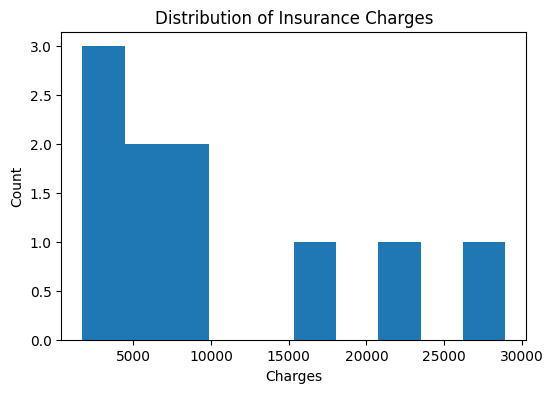

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df["charges"], bins=10)
plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Count")
plt.show()


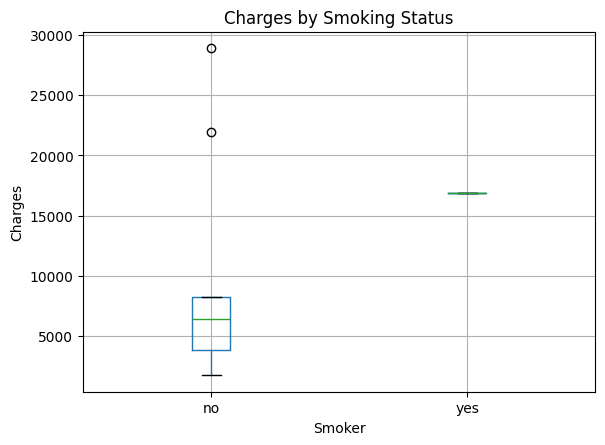

In [22]:
df.boxplot(column="charges", by="smoker")
plt.title("Charges by Smoking Status")
plt.suptitle("")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()


In [23]:
df.isnull().sum()
df.duplicated().sum()


np.int64(0)

In [24]:
categorical_features = ["sex", "smoker", "region"]
numeric_features = ["age", "bmi", "children"]

categorical_features, numeric_features


(['sex', 'smoker', 'region'], ['age', 'bmi', 'children'])

In [25]:
X = df.drop("charges", axis=1)
y = df["charges"]

X.head(), y.head()


(   age     sex     bmi  children smoker     region
 0   19  female  27.900         0    yes  southwest
 1   18    male  33.770         1     no  southeast
 2   28    male  33.000         3     no  southeast
 3   33    male  22.705         0     no  northwest
 4   32    male  28.880         0     no  northwest,
 0    16884.92
 1     1725.55
 2     4449.46
 3    21984.47
 4     3866.85
 Name: charges, dtype: float64)

In [26]:
X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded.head()


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((8, 8), (2, 8))

In [28]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
y_pred = model.predict(X_test)
y_pred


array([ 23724.03821692, -12736.56894755])

In [30]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))


R2 Score: -45.46669727208329
MAE: 15889.873582235627


In [32]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
rf_pred = rf_model.predict(X_test)
rf_pred


array([8953.8665, 7465.541 ])

In [34]:
from sklearn.metrics import r2_score, mean_absolute_error

print("Random Forest R2:", r2_score(y_test, rf_pred))
print("Random Forest MAE:", mean_absolute_error(y_test, rf_pred))


Random Forest R2: -2.5998375832738105
Random Forest MAE: 4143.723749999999


In [35]:
import pandas as pd

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance


age                 0.408590
bmi                 0.278874
region_southeast    0.112822
region_southwest    0.076596
children            0.060028
smoker_yes          0.028157
sex_male            0.024273
region_northwest    0.010660
dtype: float64

In [36]:
import pandas as pd

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance


age                 0.408590
bmi                 0.278874
region_southeast    0.112822
region_southwest    0.076596
children            0.060028
smoker_yes          0.028157
sex_male            0.024273
region_northwest    0.010660
dtype: float64

In [37]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [None, 5, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [38]:
best_model = grid.best_estimator_
grid.best_params_


{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}

In [39]:
final_pred = best_model.predict(X_test)

from sklearn.metrics import r2_score, mean_absolute_error

print("Final R2:", r2_score(y_test, final_pred))
print("Final MAE:", mean_absolute_error(y_test, final_pred))


Final R2: -4.0121417897017535
Final MAE: 5116.256112857145


In [40]:
import joblib

joblib.dump(best_model, "../models/premium_predictor.joblib")


FileNotFoundError: [Errno 2] No such file or directory: '../models/premium_predictor.joblib'

In [41]:
from pathlib import Path

Path("../models").mkdir(parents=True, exist_ok=True)
print("models folder created (or already existed)")


models folder created (or already existed)


In [42]:
import joblib

joblib.dump(best_model, "../models/premium_predictor.joblib")
print("Model saved successfully")


Model saved successfully


In [43]:
import json

feature_cols = list(X_train.columns)

with open("../models/feature_columns.json", "w") as f:
    json.dump(feature_cols, f)

print("Feature columns saved")


Feature columns saved


In [44]:
import os
os.listdir("../models")


['feature_columns.json', 'premium_predictor.joblib']

In [45]:
import json
import joblib
import pandas as pd
from pathlib import Path

MODEL_PATH = Path("../models/premium_predictor.joblib")
COLS_PATH  = Path("../models/feature_columns.json")

# Load saved artifacts
model = joblib.load(MODEL_PATH)
feature_columns = json.loads(COLS_PATH.read_text())

def predict_premium(age, sex, bmi, children, smoker, region):
    """
    Takes raw user inputs and returns predicted premium.
    """
    # 1) Create a one-row dataframe with raw fields (same as original dataset)
    raw = pd.DataFrame([{
        "age": age,
        "sex": sex,
        "bmi": bmi,
        "children": children,
        "smoker": smoker,
        "region": region
    }])

    # 2) One-hot encode
    encoded = pd.get_dummies(raw, drop_first=True)

    # 3) Align columns to training schema (add missing columns as 0)
    encoded = encoded.reindex(columns=feature_columns, fill_value=0)

    # 4) Predict
    pred = model.predict(encoded)[0]
    return float(pred)


In [46]:
predict_premium(
    age=32,
    sex="male",
    bmi=28.88,
    children=0,
    smoker="no",
    region="northwest"
)


9351.520999523813

In [47]:
predict_premium(
    age=45,
    sex="female",
    bmi=33.4,
    children=2,
    smoker="yes",
    region="southeast"
)


10252.384259523813

In [48]:
{"predicted_premium": 12345.67}


{'predicted_premium': 12345.67}